In [1]:
import pandas as pd
import os
import json 

annotated_comments_dir = 'annotated_comments/{newspaper}'
annotated_metadata_dir = 'annotated_metadata/{newspaper}'

newspapers = ["corriere_della_sera", "repubblica", "lastampa", "ilmessaggero", "il_gazzettino"]

In [2]:

all_comments_gold = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _gold at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_gold.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_gold.json'))
    matching_ids = set(f.split('_gold')[0] for f in comment_files) & set(f.split('_gold')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_gold.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_gold.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_gold.append(comments_df)

In [3]:

all_comments_silver = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _gold at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_gold.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_gold.json'))
    matching_ids = set(f.split('_gold')[0] for f in comment_files) & set(f.split('_gold')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_silver.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_silver.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_silver.append(comments_df)

FileNotFoundError: [Errno 2] No such file or directory: 'annotated_comments/corriere_della_sera/lSaNEVCmKmY_silver.csv'

In [4]:
all_comments_gold_df = pd.concat(all_comments_gold, ignore_index=True)
print(f"Length of all comments: {len(all_comments_gold_df)}")

Length of all comments: 776


In [5]:
all_comments_gold_df

,comment_id,parent_comment_id,video_id,is_reply,author,published_at,updated_at,like_count,text,inferred_parent_id,depth,newspaper,author_anon,annotator_number,label,type,topic
0,UgzpDJqbbej3whZhgI94AaABAg,NaN,lSaNEVCmKmY,False,author_4237,2026-05-16T16:33:18Z,2026-05-16T16:33:18Z,7,Riposa in Pace 😢,NaN,0,corriere_della_sera,author_4237,1,0,gold,"disaster, accident and emergency incident"
1,UgyGkga9GmgzW-mZMDl4AaABAg,NaN,lSaNEVCmKmY,False,author_4238,2026-05-16T16:49:16Z,2026-05-16T16:49:16Z,2,Mi dispiace😢❤,NaN,0,corriere_della_sera,author_4238,1,0,gold,"disaster, accident and emergency incident"
2,UgwNnG1cEdWCq05PAsB4AaABAg,NaN,lSaNEVCmKmY,False,author_4238,2026-05-16T16:49:25Z,2026-05-16T16:49:25Z,1,R.i.p❤,NaN,0,corriere_della_sera,author_4238,1,0,gold,"disaster, accident and emergency incident"
3,Ugyy5V3XfyEqGf88jot4AaABAg,NaN,lSaNEVCmKmY,False,author_3856,2026-05-16T16:53:45Z,2026-05-16T16:53:45Z,0,😢😢😢😢😢😢😢,NaN,0,corriere_della_sera,author_3856,1,0,gold,"disaster, accident and emergency incident"
4,UgzTn8yxb_cIN-FgQp54AaABAg,NaN,lSaNEVCmKmY,False,author_469,2026-05-16T17:04:28Z,2026-05-16T17:04:28Z,1,Lancia una borsa di studio dal balcone?,NaN,0,corriere_della_sera,author_469,1,0,gold,"disaster, accident and emergency incident"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,Ugw0RLkSjkgKiNKBBUV4AaABAg.AWlE2wqhgYBAWpK2j-k3vt,Ugw0RLkSjkgKiNKBBUV4AaABAg.AWlE2wqhgYBAWnBQRiY0XY,VCwqO9o8mLc,True,author_6855,2026-05-15T10:47:26Z,2026-05-15T10:47:26Z,0,@user,Ugw0RLkSjkgKiNKBBUV4AaABAg.AWlE2wqhgYBAWnBQRiY0XY,2,il_gazzettino,author_6855,3,0,gold,"crime, law and justice"
772,UgxTpRmYpaT6eDBfiwl4AaABAg,NaN,VCwqO9o8mLc,False,author_6856,2026-05-15T13:54:51Z,2026-05-15T13:54:51Z,0,E con questo cosa vuol dire? Che e' una person...,NaN,0,il_gazzettino,author_6856,3,0,gold,"crime, law and justice"
773,Ugx6OtbBhvYSPVdAa1h4AaABAg.AWmilwhHflLAWptAUhjd3D,Ugx6OtbBhvYSPVdAa1h4AaABAg,VCwqO9o8mLc,True,author_6447,2026-05-15T16:03:04Z,2026-05-15T16:03:04Z,0,Un ladro onesto non ruba😂,Ugx6OtbBhvYSPVdAa1h4AaABAg,1,il_gazzettino,author_6447,3,0,gold,"crime, law and justice"
774,Ugw0RLkSjkgKiNKBBUV4AaABAg.AWlE2wqhgYBAWq7ihWFKRh,Ugw0RLkSjkgKiNKBBUV4AaABAg,VCwqO9o8mLc,True,author_6857,2026-05-15T18:18:57Z,2026-05-15T18:18:57Z,1,😂😂😂,Ugw0RLkSjkgKiNKBBUV4AaABAg,1,il_gazzettino,author_6857,3,0,gold,"crime, law and justice"


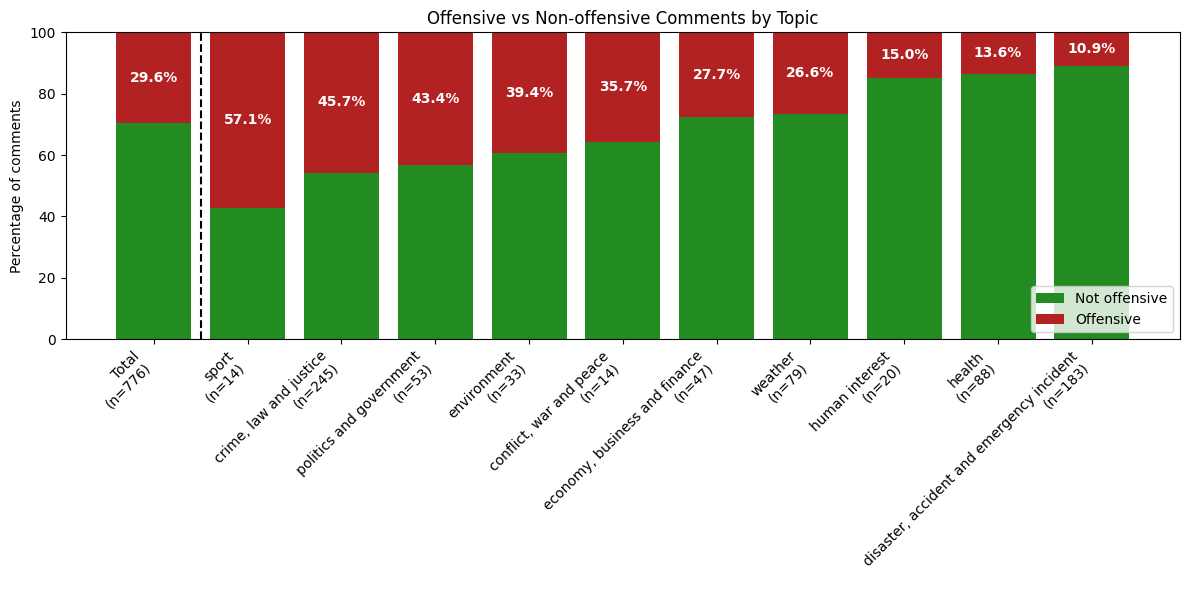

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = all_comments_gold_df

# Overall stats
overall_off = df["label"].mean() * 100
overall_n = len(df)

# Topic stats
topic_stats = (
    df.groupby("topic")
    .agg(
        offensive=("label", lambda x: x.mean() * 100),
        n=("label", "size")
    )
    .sort_values("offensive", ascending=False)
)

# Build plotting dataframe
plot_df = pd.concat([
    pd.DataFrame({
        "offensive": [overall_off],
        "n": [overall_n]
    }, index=["Total"]),
    topic_stats
])

plot_df["non_offensive"] = 100 - plot_df["offensive"]

# X labels with sample size
labels = [
    f"{topic}\n(n={n:,})"
    for topic, n in zip(plot_df.index, plot_df["n"])
]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(plot_df))

# Stacked bars
ax.bar(
    x,
    plot_df["non_offensive"],
    color="forestgreen",
    label="Not offensive"
)

ax.bar(
    x,
    plot_df["offensive"],
    bottom=plot_df["non_offensive"],
    color="firebrick",
    label="Offensive"
)

# Offensive percentage labels
for i, off in enumerate(plot_df["offensive"]):
    ax.text(
        i,
        100 - off / 2,
        f"{off:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold"
    )

# Separator between Total and topics
ax.axvline(
    x=0.5,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Percentage of comments")
ax.set_title("Offensive vs Non-offensive Comments by Topic")
ax.legend()

plt.tight_layout()
plt.show()

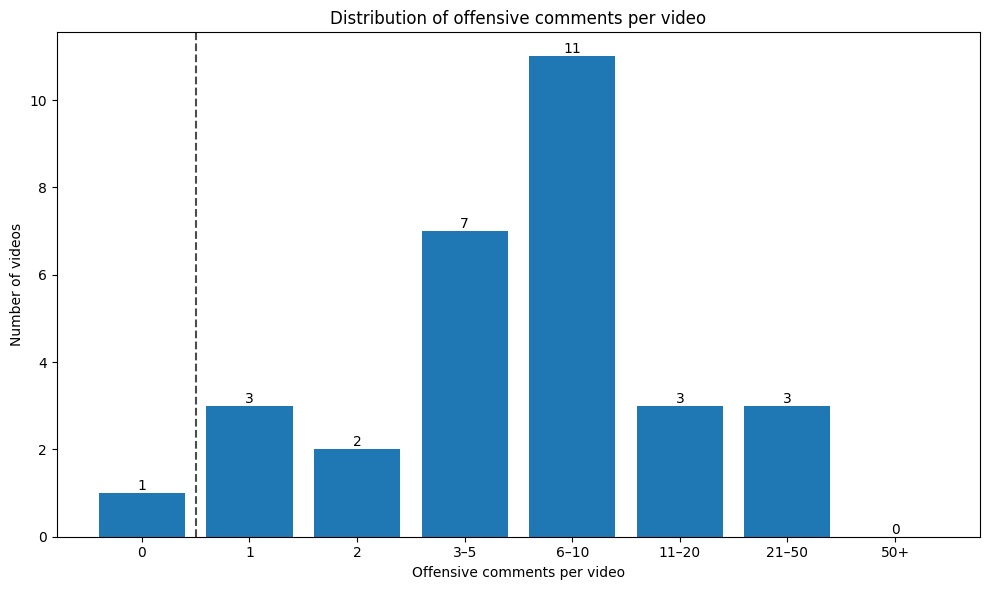

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Offensive comments per video
offensive_per_video = df.groupby("video_id")["label"].sum()

# 0 bucket
n_zero = (offensive_per_video == 0).sum()

# positives
positive = offensive_per_video[offensive_per_video > 0]

# manual binning (safe)
bins = {
    "1": (1, 1),
    "2": (2, 2),
    "3–5": (3, 5),
    "6–10": (6, 10),
    "11–20": (11, 20),
    "21–50": (21, 50),
    "50+": (51, float("inf"))
}

counts = {}

for label, (low, high) in bins.items():
    counts[label] = ((positive >= low) & (positive <= high)).sum()

# combine with zero
plot_data = pd.Series({"0": n_zero})
plot_data = pd.concat([plot_data, pd.Series(counts)])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_data.index, plot_data.values)

# separator after 0
ax.axvline(0.5, linestyle="--", color="black", alpha=0.7)

# labels
for i, v in enumerate(plot_data.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

ax.set_xlabel("Offensive comments per video")
ax.set_ylabel("Number of videos")
ax.set_title("Distribution of offensive comments per video")

plt.tight_layout()
plt.show()

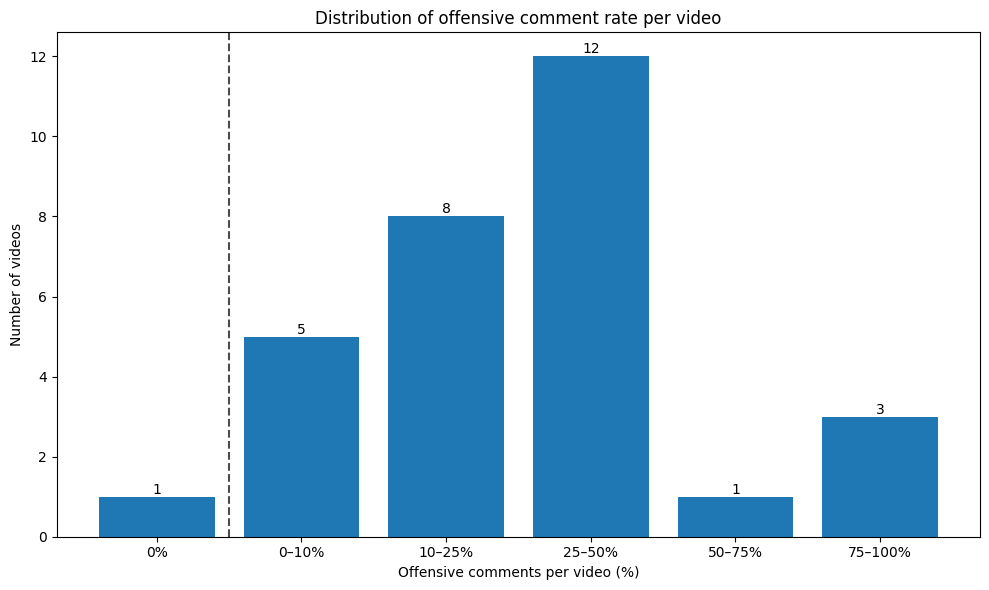

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Offensive rate per video (%)
off_rate = df.groupby("video_id")["label"].mean() * 100

# Split zero vs non-zero
zero = (off_rate == 0).sum()
positive = off_rate[off_rate > 0]

# Percentage bins
bins = {
    "0%": (0, 0),
    "0–10%": (0.0001, 10),
    "10–25%": (10, 25),
    "25–50%": (25, 50),
    "50–75%": (50, 75),
    "75–100%": (75, 100),
}

counts = {}

# handle 0 separately (clean separation)
counts["0%"] = zero

# bin only positives
for label, (low, high) in bins.items():
    if label == "0%":
        continue
    counts[label] = ((positive > low) & (positive <= high)).sum()

plot_data = pd.Series(counts)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(plot_data.index, plot_data.values)

# separator after 0%
ax.axvline(0.5, linestyle="--", color="black", alpha=0.7)

# labels
for i, v in enumerate(plot_data.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

ax.set_xlabel("Offensive comments per video (%)")
ax.set_ylabel("Number of videos")
ax.set_title("Distribution of offensive comment rate per video")

plt.tight_layout()
plt.show()